In [1]:
# 1) Import required library
import pandas as pd

# 2) Load the CSV file
# Keep this file in the same folder as this notebook
df = pd.read_csv("IMDB Dataset.csv")

# 3) Display first 5 rows
print("First 5 rows:")
display(df.head())

# 4) Print dataset shape (rows, columns)
print("\nDataset shape (rows, columns):")
print(df.shape)

# 5) Print column names
print("\nColumn names:")
print(df.columns.tolist())

# 6) Check data types
print("\nData types:")
print(df.dtypes)

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Dataset shape (rows, columns):
(50000, 2)

Column names:
['review', 'sentiment']

Data types:
review       str
sentiment    str
dtype: object


In [2]:
df.isnull().sum() # null values 

review       0
sentiment    0
dtype: int64

In [3]:
df.drop_duplicates(inplace=True) # remove duplicate 

In [4]:
df.shape

(49582, 2)


Class Distribution:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


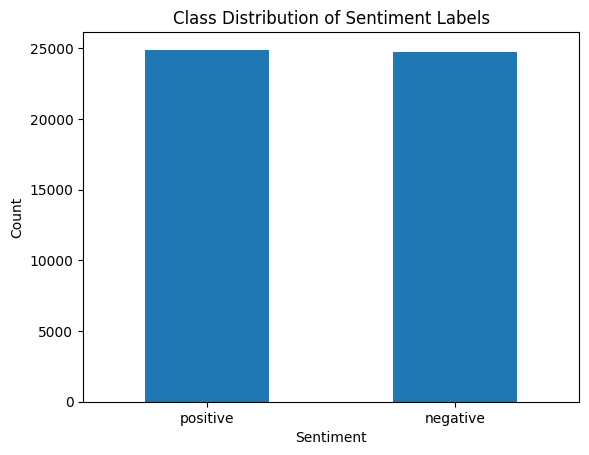

In [5]:
#  Class Distribution of Sentiment Labels
import matplotlib.pyplot as plt
print("\nClass Distribution:")
print(df['sentiment'].value_counts())

# Plot class distribution
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Class Distribution of Sentiment Labels")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [6]:
# 2. Check Whether Dataset is Balanced or Not
class_counts = df['sentiment'].value_counts()

print("\nChecking balance of dataset:")
print(class_counts)

if abs(class_counts['positive'] - class_counts['negative']) <= 0.05 * len(df):
    print("\n✅ The dataset is BALANCED.")
else:
    print("\n⚠️ The dataset is NOT BALANCED.")


Checking balance of dataset:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64

✅ The dataset is BALANCED.


In [7]:
# 3. Sample Positive and Negative Reviews
# -----------------------------------------
print("\nSample Positive Reviews:")
print(df[df['sentiment'] == 'positive']['review'].head(3))

print("\nSample Negative Reviews:")
print(df[df['sentiment'] == 'negative']['review'].head(3))


Sample Positive Reviews:
0    One of the other reviewers has mentioned that ...
1    A wonderful little production. <br /><br />The...
2    I thought this was a wonderful way to spend ti...
Name: review, dtype: str

Sample Negative Reviews:
3    Basically there's a family where a little boy ...
7    This show was an amazing, fresh & innovative i...
8    Encouraged by the positive comments about this...
Name: review, dtype: str


In [8]:
import seaborn as sns
# 1. Calculate Review Length (Word Count)

df['review_length'] = df['review'].apply(lambda x: len(x.split()))
print(df[['review', 'review_length']].head())


                                              review  review_length
0  One of the other reviewers has mentioned that ...            307
1  A wonderful little production. <br /><br />The...            162
2  I thought this was a wonderful way to spend ti...            166
3  Basically there's a family where a little boy ...            138
4  Petter Mattei's "Love in the Time of Money" is...            230


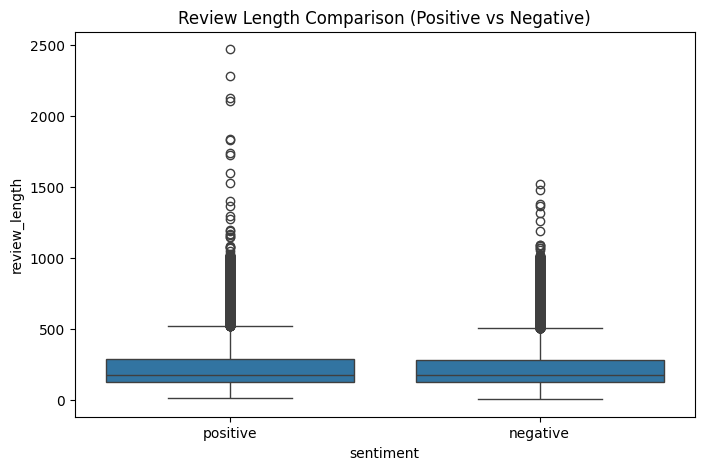

In [9]:

# 2. Compare Positive vs Negative Length

plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment', y='review_length', data=df)
plt.title("Review Length Comparison (Positive vs Negative)")
plt.show()

#Positive reviews have slightly more extreme long outliers

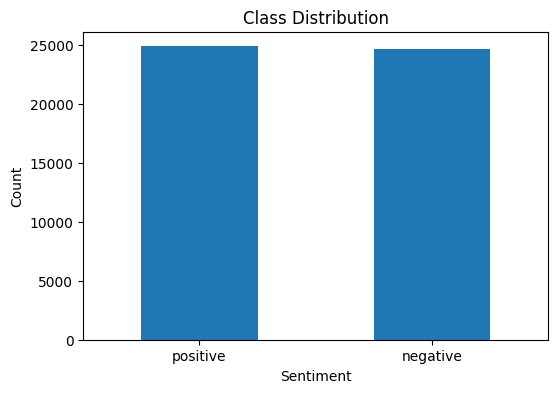

In [10]:
# 3. Class Distribution

plt.figure(figsize=(6,4))
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

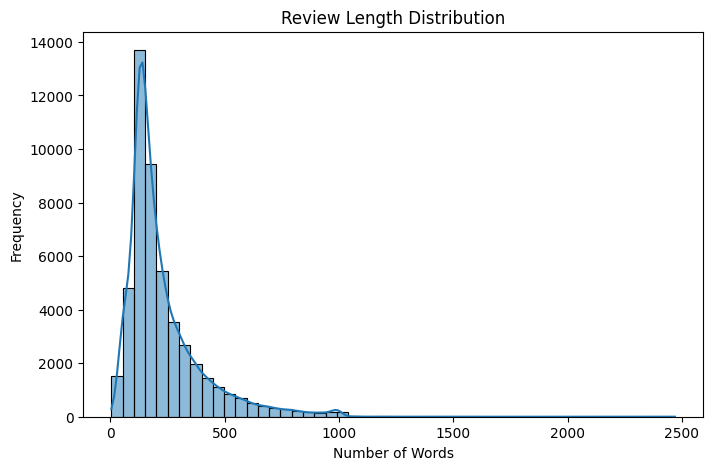

In [11]:
# 4. Review Length Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['review_length'], bins=50, kde=True)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

 - Review lengths are right-skewed with most reviews under 300 words
 - Positive and negative reviews have similar length distributions
 - No strong correlation between length and sentiment
 - Optimal sequence length should be around 200–300 words
 - Outliers exist and should be truncated during preprocessing

# text preprocessing

In [12]:
import re

def clean_text(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # 3. Replace special characters with space (IMPORTANT FIX)
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # 4. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [13]:
df['cleaned_review'] = df['review'].apply(clean_text)

# Check result
print("Before Cleaning:\n", df['review'][0])
print("\nAfter Cleaning:\n", df['cleaned_review'][0])

Before Cleaning:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

In [14]:
df['cleaned_review'].apply(len).describe()

count    49582.000000
mean      1249.435138
std        945.473620
min         30.000000
25%        669.000000
50%        926.000000
75%       1515.000000
max      13315.000000
Name: cleaned_review, dtype: float64

In [15]:
# Convert sentiment labels into numeric format
df['label']=df['sentiment'].map({
    'positive': 1,
    'negative': 0
})


In [16]:
df

,review,sentiment,review_length,cleaned_review,label
0,One of the other reviewers has mentioned that ...,positive,307,one of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,positive,162,a wonderful little production the filming tech...,1
2,I thought this was a wonderful way to spend ti...,positive,166,i thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,negative,138,basically there s a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,petter mattei s love in the time of money is a...,1
...,...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,194,i thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,112,bad plot bad dialogue bad acting idiotic direc...,0
49997,I am a Catholic taught in parochial elementary...,negative,230,i am a catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,negative,212,i m going to have to disagree with the previou...,0


In [17]:
from sklearn.model_selection import train_test_split

X = df['cleaned_review']
y = df['label']
X_train,X_test,y_train,y_test=train_test_split(
    X, y,test_size=0.2, random_state=42
)



# Build TF-IDF + Logistic Regression Baseline

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#  TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [19]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

# Train and evaluate each model
for name, model in models.items():
    print("-" * 60)
    print(f"Model: {name}")
    
    # Train
    model.fit(X_train_tfidf, y_train)
    
    # Predict
    y_pred = model.predict(X_test_tfidf)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    
    # Confusion Matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

------------------------------------------------------------
Model: Logistic Regression
Accuracy: 0.8882

Confusion Matrix:
[[4321  618]
 [ 491 4487]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4939
           1       0.88      0.90      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917

------------------------------------------------------------
Model: Naive Bayes
Accuracy: 0.8511

Confusion Matrix:
[[4168  771]
 [ 706 4272]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      4939
           1       0.85      0.86      0.85      4978

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917

----

Three traditional machine learning models were compared using TF-IDF features: Logistic Regression, Multinomial Naive Bayes, and Linear SVM. Logistic Regression achieved the highest accuracy (88.82%) and the most balanced classification performance across both sentiment classes. Linear SVM performed competitively but slightly below Logistic Regression, while Naive Bayes showed comparatively lower performance. Therefore, Logistic Regression was selected as the best baseline model.

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Improved TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),#Uses both single words (unigrams) and two-word combinations (bigrams) so the model can understand phrases like “not good”.
    min_df=2, #Ignores words that appear in less than 2 documents, because they are usually too rare and not useful for learning.
    max_df=0.95, #Ignores words that appear in more than 95% of documents, because they are too common and carry little sentiment meaning.
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Improved Logistic Regression
model = LogisticRegression(
    C=2,# allows the model to fit the training data a little more strongly than the default.
    max_iter=1000
)

# Train
model.fit(X_train_tfidf, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [21]:
# Predict
y_pred = model.predict(X_test_tfidf)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9024906725824342

Confusion Matrix:
[[4398  541]
 [ 426 4552]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4939
           1       0.89      0.91      0.90      4978

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



In [28]:
# def predict_sentiment(review):
#     # Step 1: Clean the review
#     cleaned = clean_text(review)
    
#     # Step 2: Convert to TF-IDF
#     vectorized = tfidf.transform([cleaned])
    
#     # Step 3: Predict label
#     prediction = model.predict(vectorized)[0]
    
#     # Step 4: Predict probability
#     probability = model.predict_proba(vectorized)[0]
    
#     # Step 5: Convert label to sentiment
#     sentiment = "Positive" if prediction == 1 else "Negative"
    
#     print("Original Review:")
#     print(review)
#     print("\nCleaned Review:")
#     print(cleaned)
#     print("\nPredicted Sentiment:", sentiment)
#     print("Prediction Probabilities:")
#     print(f"Negative: {probability[0]:.4f}")
#     print(f"Positive: {probability[1]:.4f}")



def predict_sentiment(review):
    # Step 1: Clean the review
    cleaned = clean_text(review)
    
    # Step 2: Convert to TF-IDF
    vectorized = tfidf.transform([cleaned])
    
    # Step 3: Predict label
    prediction = model.predict(vectorized)[0]
    
    # Step 4: Predict probability
    probability = model.predict_proba(vectorized)[0]
    
    # Step 5: Convert label to sentiment
    sentiment = "Positive" if prediction == 1 else "Negative"
    
    print("\nOriginal Review:")
    print(review)
    print("\nCleaned Review:")
    print(cleaned)
    print("\nPredicted Sentiment:", sentiment)
    print("Prediction Probabilities:")
    print(f"Negative: {probability[0]:.4f}")
    print(f"Positive: {probability[1]:.4f}")


# Take user input
user_review = input("Enter a movie review: ")

# Predict sentiment
predict_sentiment(user_review)


Original Review:
This movie was absolutely amazing, I loved every moment of it!

Cleaned Review:
this movie was absolutely amazing i loved every moment of it

Predicted Sentiment: Positive
Prediction Probabilities:
Negative: 0.0328
Positive: 0.9672


In [29]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))